# Paper Results: Survey x Simulation

This notebook mixes the two sides of the project:

- `survey_results.ipynb` explains and explores the human survey data.
- `simulation_results.ipynb` explains and explores the logged simulation benchmark data.
- This file checks whether the simulation benchmark agrees with the survey outcomes.

The main question here is not whether the scores are numerically identical. The survey is a human rating on a `-3..+3` Likert-style scale, while the simulation benchmark is a normalized objective score on `0..1`. The question is whether they tell the same story when we compare the same policy/POV pairs.

## Decision Logic

We will treat this as an alignment check:

1. Import and clean the survey answers.
2. Import and aggregate the simulation metrics.
3. Put both datasets on comparable condition/axis labels.
4. Compare rankings and paired differences, not raw absolute scores.
5. Mark where the simulation and survey agree, disagree, or are too close to call.

Useful references for the methods used here:

- Exploratory data analysis: [NIST/SEMATECH EDA handbook](https://www.nist.gov/publications/nistsematech-e-handbook-statistical-methods-chapter-1-exploratory-data-analysis)
- Bootstrap confidence intervals: [SciPy `stats.bootstrap`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html)
- Rank correlation / Spearman idea: [SciPy `stats.spearmanr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html)

We implement the bootstrap and rank correlation directly with `numpy`/`pandas` so this notebook does not require SciPy.

## Imports And Shared Mappings

In [42]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

# The notebook may run from the repository root or from paper/notebooks.
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent.parent

SURVEY_CSV = project_root / "paper" / "data" / "human-survey" / "raw-responses2.csv"
SIMULATION_ROOT = project_root / "artifacts" / "local-validation"

RANDOM_SEED = 20260514


In [43]:
Q_MAPPING = {
    "q1": {"policy": "A", "pov": "first_person", "condition_label": "Policy A - first person"},
    "q2": {"policy": "B", "pov": "first_person", "condition_label": "Policy B - first person"},
    "q3": {"policy": "A", "pov": "third_person", "condition_label": "Policy A - third person"},
    "q4": {"policy": "B", "pov": "third_person", "condition_label": "Policy B - third person"},
}

SURVEY_QUESTION_AXIS = {
    "1": "competence_control",
    "2": "safety",
    "3": "awareness",
    "4": "positive_impression",
}

SIMULATION_AXIS_MAP = {
    "perceived_dexterity": "competence_control",
    "perceived_safety": "safety",
    "perceived_social_awareness": "awareness",
    "impression": "positive_impression",
}

EPISODE_LABELS = {
    "ep1": "no_obstacles",
    "ep2": "fixed_obstacles",
    "ep3": "moving_people",
}

AXES = ["competence_control", "safety", "awareness", "positive_impression"]
AXES_WITH_GLOBAL = ["global"] + AXES

COMPARISONS = [
    ("q1", "q2", "A vs B - first-person POV", "Policy A minus Policy B, first-person videos"),
    ("q3", "q4", "A vs B - third-person POV", "Policy A minus Policy B, third-person videos"),
    ("q1", "q3", "First vs third POV - Policy A", "First-person minus third-person for Policy A"),
    ("q2", "q4", "First vs third POV - Policy B", "First-person minus third-person for Policy B"),
]

## Import Survey Results

The survey data is participant-level. Every participant saw all four videos, so policy and POV comparisons are paired within participant. We keep that paired structure when computing differences.

In [44]:
def convert_answer_to_number(answer):
    answer_text = str(answer)
    for score_text, score_number in {"-3": -3, "-2": -2, "-1": -1, "0": 0, "+1": 1, "+2": 2, "+3": 3}.items():
        if answer_text.startswith(score_text):
            return score_number
    return np.nan


def familiarity_to_boolean(answer):
    answer_text = str(answer)
    if answer_text == "True" or answer_text.startswith("Daily interaction"):
        return True
    if answer_text == "False" or answer_text.startswith("No daily contact"):
        return False
    return pd.NA


raw_survey = pd.read_csv(SURVEY_CSV)

rename_columns = {}
for old_column_name in raw_survey.columns:
    if old_column_name == "Timestamp":
        rename_columns[old_column_name] = "timestamp"
    elif old_column_name.startswith("Background / Familiarity"):
        rename_columns[old_column_name] = "robotics_familiarity"
    elif old_column_name.startswith("Q"):
        question_code = old_column_name.split(" ", 1)[0]
        rename_columns[old_column_name] = question_code.lower().replace(".", "_")

survey_wide = raw_survey.rename(columns=rename_columns).copy()
survey_wide.insert(0, "participant_id", np.arange(1, len(survey_wide) + 1))

score_columns = [column for column in survey_wide.columns if re.fullmatch(r"q[1-4]_[1-4]", column)]
for column in score_columns:
    survey_wide[column] = survey_wide[column].apply(convert_answer_to_number)

survey_wide["robotics_familiarity"] = survey_wide["robotics_familiarity"].apply(familiarity_to_boolean).astype("boolean")

survey_rows = []
for condition, metadata in Q_MAPPING.items():
    for question_number, axis in SURVEY_QUESTION_AXIS.items():
        column = f"{condition}_{question_number}"
        if column not in survey_wide.columns:
            continue
        for _, row in survey_wide.iterrows():
            survey_rows.append(
                {
                    "participant_id": row["participant_id"],
                    "robotics_familiarity": row["robotics_familiarity"],
                    "condition": condition,
                    "condition_label": metadata["condition_label"],
                    "policy": metadata["policy"],
                    "pov": metadata["pov"],
                    "axis": axis,
                    "score": row[column],
                }
            )

survey_long = pd.DataFrame(survey_rows)
survey_long["score_norm"] = (survey_long["score"] + 3) / 6

survey_global = (
    survey_long.groupby(["participant_id", "robotics_familiarity", "condition", "condition_label", "policy", "pov"], dropna=False)
    .agg(score=("score", "mean"), score_norm=("score_norm", "mean"))
    .reset_index()
)
survey_global["axis"] = "global"

survey_analysis_long = pd.concat([survey_long, survey_global], ignore_index=True, sort=False)

print(f"Survey participants: {survey_wide['participant_id'].nunique()}")
print(f"Survey long rows including global: {len(survey_analysis_long)}")
display(survey_analysis_long.head())

Survey participants: 120
Survey long rows including global: 2400


,participant_id,robotics_familiarity,condition,condition_label,policy,pov,axis,score,score_norm
0,1,True,q1,Policy A - first person,A,first_person,competence_control,1.0,0.666667
1,2,True,q1,Policy A - first person,A,first_person,competence_control,2.0,0.833333
2,3,False,q1,Policy A - first person,A,first_person,competence_control,-1.0,0.333333
3,4,False,q1,Policy A - first person,A,first_person,competence_control,2.0,0.833333
4,5,False,q1,Policy A - first person,A,first_person,competence_control,-1.0,0.333333


In [45]:
survey_keys = ["condition", "condition_label", "policy", "pov", "axis"]

survey_summary = (
    survey_analysis_long.groupby(survey_keys, dropna=False)
    .agg(
        n=("score", "count"),
        survey_mean_raw=("score", "mean"),
        survey_median_raw=("score", "median"),
        survey_mean_0_1=("score_norm", "mean"),
        survey_median_0_1=("score_norm", "median"),
        survey_std_0_1=("score_norm", "std"),
    )
    .reset_index()
)

survey_polarity = (
    survey_analysis_long.assign(
        negative=survey_analysis_long["score"] < 0,
        neutral=survey_analysis_long["score"] == 0,
        positive=survey_analysis_long["score"] > 0,
    )
    .groupby(survey_keys, dropna=False)[["negative", "neutral", "positive"]]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"negative": "percent_negative", "neutral": "percent_neutral", "positive": "percent_positive"})
)

survey_summary = survey_summary.merge(survey_polarity, on=survey_keys, how="left")

display(survey_summary.sort_values(["axis", "condition"]))

,condition,condition_label,policy,pov,axis,n,survey_mean_raw,survey_median_raw,survey_mean_0_1,survey_median_0_1,survey_std_0_1,percent_negative,percent_neutral,percent_positive
0,q1,Policy A - first person,A,first_person,awareness,120,-0.883333,-1.000,0.352778,0.333333,0.283521,70.833333,3.333333,25.833333
5,q2,Policy B - first person,B,first_person,awareness,119,-0.722689,-1.000,0.379552,0.333333,0.286156,56.666667,11.666667,30.833333
10,q3,Policy A - third person,A,third_person,awareness,120,-0.775000,-1.000,0.370833,0.333333,0.252404,66.666667,7.500000,25.833333
15,q4,Policy B - third person,B,third_person,awareness,120,-1.016667,-2.000,0.330556,0.166667,0.275843,68.333333,8.333333,23.333333
1,q1,Policy A - first person,A,first_person,competence_control,120,0.183333,1.000,0.530556,0.666667,0.276688,39.166667,9.166667,51.666667
6,q2,Policy B - first person,B,first_person,competence_control,120,-0.808333,-1.000,0.365278,0.333333,0.274411,62.500000,8.333333,29.166667
11,q3,Policy A - third person,A,third_person,competence_control,120,0.416667,1.000,0.569444,0.666667,0.260703,34.166667,11.666667,54.166667
16,q4,Policy B - third person,B,third_person,competence_control,120,-0.941667,-1.000,0.343056,0.333333,0.240890,73.333333,7.500000,19.166667
2,q1,Policy A - first person,A,first_person,global,120,-0.335417,-0.500,0.444097,0.416667,0.241420,57.500000,5.833333,36.666667
7,q2,Policy B - first person,B,first_person,global,120,-0.715278,-0.875,0.380787,0.354167,0.237413,68.333333,5.000000,26.666667


## Import Simulation Results

The simulation data is episode-level. It has repeated logged runs, not human participants. We aggregate repeated runs within each `condition x episode x axis`, then summarize across the three episode slots.

In [46]:
def metadata_from_csv_path(path: Path) -> dict:
    relative_parts = path.relative_to(SIMULATION_ROOT).parts
    condition = relative_parts[0] if relative_parts else None
    run_label = relative_parts[1] if len(relative_parts) > 1 else path.parent.name
    episode_match = re.search(r"ep(\d+)", run_label)
    episode_slot = f"ep{episode_match.group(1)}" if episode_match else None
    metadata = Q_MAPPING.get(condition, {})
    return {
        "condition": condition,
        "condition_label": metadata.get("condition_label"),
        "policy": metadata.get("policy"),
        "pov": metadata.get("pov"),
        "episode_slot": episode_slot,
        "episode_type": EPISODE_LABELS.get(episode_slot),
        "run_label": run_label,
        "csv_path": str(path),
    }


simulation_csv_paths = sorted(SIMULATION_ROOT.rglob("episode-metrics-*.csv"))
if not simulation_csv_paths:
    raise FileNotFoundError(f"No simulation CSV files found under {SIMULATION_ROOT.resolve()}")

simulation_frames = []
for csv_path in simulation_csv_paths:
    frame = pd.read_csv(csv_path)
    for key, value in metadata_from_csv_path(csv_path).items():
        frame[key] = value
    simulation_frames.append(frame)

simulation_raw = pd.concat(simulation_frames, ignore_index=True)

for column in SIMULATION_AXIS_MAP:
    simulation_raw[column] = pd.to_numeric(simulation_raw[column], errors="coerce")

if "technical_valid" in simulation_raw.columns:
    simulation_raw["technical_valid_bool"] = simulation_raw["technical_valid"].astype(str).str.lower().eq("true")

simulation_episode_axes = (
    simulation_raw.groupby(["condition", "condition_label", "policy", "pov", "episode_slot", "episode_type"], dropna=False)[list(SIMULATION_AXIS_MAP)]
    .mean()
    .reset_index()
    .rename(columns=SIMULATION_AXIS_MAP)
)

simulation_axis_long = simulation_episode_axes.melt(
    id_vars=["condition", "condition_label", "policy", "pov", "episode_slot", "episode_type"],
    value_vars=AXES,
    var_name="axis",
    value_name="sim_score",
).dropna(subset=["sim_score"])

simulation_global = (
    simulation_axis_long.groupby(["condition", "condition_label", "policy", "pov", "episode_slot", "episode_type"], dropna=False)
    .agg(sim_score=("sim_score", "mean"))
    .reset_index()
)
simulation_global["axis"] = "global"

simulation_analysis_long = pd.concat([simulation_axis_long, simulation_global], ignore_index=True, sort=False)

print(f"Simulation rows: {len(simulation_raw)}")
print(f"Simulation CSV files: {len(simulation_csv_paths)}")
display(simulation_analysis_long.head())

Simulation rows: 12
Simulation CSV files: 12


,condition,condition_label,policy,pov,episode_slot,episode_type,axis,sim_score
0,q1,Policy A - first person,A,first_person,ep1,no_obstacles,competence_control,0.928571
1,q1,Policy A - first person,A,first_person,ep2,fixed_obstacles,competence_control,0.916843
2,q1,Policy A - first person,A,first_person,ep3,moving_people,competence_control,0.682330
3,q2,Policy B - first person,B,first_person,ep1,no_obstacles,competence_control,0.850004
4,q2,Policy B - first person,B,first_person,ep2,fixed_obstacles,competence_control,0.693346


In [47]:
simulation_keys = ["condition", "condition_label", "policy", "pov", "axis"]

simulation_summary = (
    simulation_analysis_long.groupby(simulation_keys, dropna=False)
    .agg(
        sim_mean_0_1=("sim_score", "mean"),
        sim_median_0_1=("sim_score", "median"),
        sim_std_0_1=("sim_score", "std"),
        n_episode_values=("sim_score", "count"),
        n_episode_slots=("episode_slot", "nunique"),
    )
    .reset_index()
)

simulation_run_quality = (
    simulation_raw.groupby(["condition", "condition_label", "policy", "pov"], dropna=False)
    .agg(
        n_logged_runs=("csv_path", "count"),
        technical_valid_rate=("technical_valid_bool", "mean") if "technical_valid_bool" in simulation_raw.columns else ("csv_path", "count"),
    )
    .reset_index()
)

simulation_summary = simulation_summary.merge(simulation_run_quality, on=["condition", "condition_label", "policy", "pov"], how="left")

display(simulation_summary.sort_values(["axis", "condition"]))

,condition,condition_label,policy,pov,axis,sim_mean_0_1,sim_median_0_1,sim_std_0_1,n_episode_values,n_episode_slots,n_logged_runs,technical_valid_rate
0,q1,Policy A - first person,A,first_person,awareness,0.835777,0.988271,0.274348,3,3,3,1.0
5,q2,Policy B - first person,B,first_person,awareness,0.530912,0.554317,0.049427,3,3,3,1.0
10,q3,Policy A - third person,A,third_person,awareness,0.835777,0.988271,0.274348,3,3,3,1.0
15,q4,Policy B - third person,B,third_person,awareness,0.474299,0.553692,0.146776,3,3,3,1.0
1,q1,Policy A - first person,A,first_person,competence_control,0.842581,0.916843,0.138905,3,3,3,1.0
6,q2,Policy B - first person,B,first_person,competence_control,0.631117,0.693346,0.255745,3,3,3,1.0
11,q3,Policy A - third person,A,third_person,competence_control,0.842581,0.916843,0.138905,3,3,3,1.0
16,q4,Policy B - third person,B,third_person,competence_control,0.630628,0.691893,0.255564,3,3,3,1.0
2,q1,Policy A - first person,A,first_person,global,0.766360,0.905702,0.249704,3,3,3,1.0
7,q2,Policy B - first person,B,first_person,global,0.504078,0.477986,0.164614,3,3,3,1.0


## Put Survey And Simulation On The Same Table

The survey score is converted to `0..1` only for comparison. A value of `0.5` means neutral on the original `-3..+3` scale. The simulation score already lives on `0..1`.

In [48]:
joint_summary = survey_summary.merge(
    simulation_summary,
    on=["condition", "condition_label", "policy", "pov", "axis"],
    how="outer",
)

joint_summary["mean_gap_sim_minus_survey"] = joint_summary["sim_mean_0_1"] - joint_summary["survey_mean_0_1"]

display(
    joint_summary[
        [
            "condition",
            "condition_label",
            "axis",
            "survey_mean_raw",
            "survey_mean_0_1",
            "sim_mean_0_1",
            "mean_gap_sim_minus_survey",
            "n",
            "n_episode_slots",
            "n_logged_runs",
            "technical_valid_rate",
        ]
    ].sort_values(["axis", "condition"])
)

,condition,condition_label,axis,survey_mean_raw,survey_mean_0_1,sim_mean_0_1,mean_gap_sim_minus_survey,n,n_episode_slots,n_logged_runs,technical_valid_rate
0,q1,Policy A - first person,awareness,-0.883333,0.352778,0.835777,0.482999,120,3,3,1.0
5,q2,Policy B - first person,awareness,-0.722689,0.379552,0.530912,0.151361,119,3,3,1.0
10,q3,Policy A - third person,awareness,-0.775000,0.370833,0.835777,0.464943,120,3,3,1.0
15,q4,Policy B - third person,awareness,-1.016667,0.330556,0.474299,0.143744,120,3,3,1.0
1,q1,Policy A - first person,competence_control,0.183333,0.530556,0.842581,0.312026,120,3,3,1.0
6,q2,Policy B - first person,competence_control,-0.808333,0.365278,0.631117,0.265839,120,3,3,1.0
11,q3,Policy A - third person,competence_control,0.416667,0.569444,0.842581,0.273137,120,3,3,1.0
16,q4,Policy B - third person,competence_control,-0.941667,0.343056,0.630628,0.287573,120,3,3,1.0
2,q1,Policy A - first person,global,-0.335417,0.444097,0.766360,0.322262,120,3,3,1.0
7,q2,Policy B - first person,global,-0.715278,0.380787,0.504078,0.123291,120,3,3,1.0


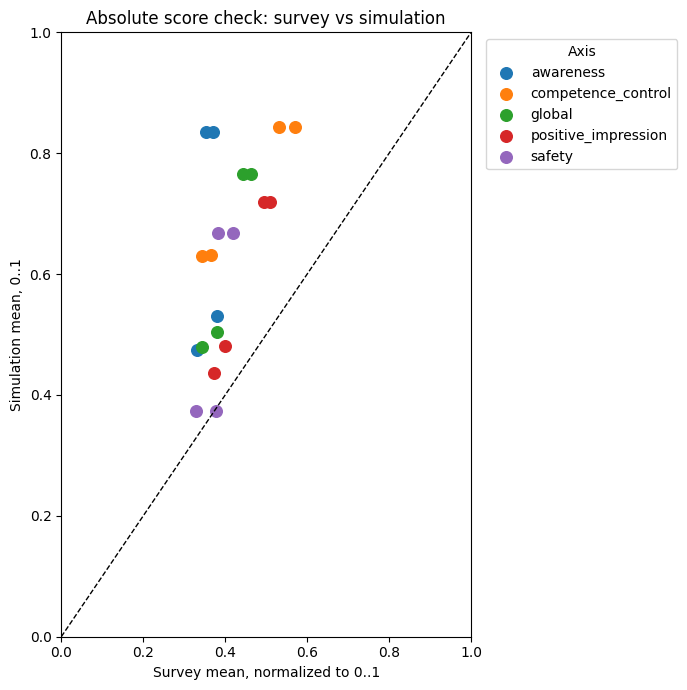

In [49]:
plot_data = joint_summary.dropna(subset=["survey_mean_0_1", "sim_mean_0_1"]).copy()

fig, ax = plt.subplots(figsize=(7, 7))
for axis_name, axis_frame in plot_data.groupby("axis"):
    ax.scatter(axis_frame["survey_mean_0_1"], axis_frame["sim_mean_0_1"], label=axis_name, s=70)

ax.axline((0, 0), slope=1, color="black", linewidth=1, linestyle="--")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Survey mean, normalized to 0..1")
ax.set_ylabel("Simulation mean, 0..1")
ax.set_title("Absolute score check: survey vs simulation")
ax.legend(title="Axis", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The scatter above is a calibration check, not the main decision. If the simulation scores are all near `1.0` while the survey scores are around neutral or negative, the benchmark may still rank policies correctly, but its absolute score scale is not calibrated to human perception.

## Paired Difference Analysis

This is the core mixed analysis. For the survey, each difference is computed within participant. For the simulation, each difference is computed within episode slot. Then we compare the direction of those differences.

We use small practical deadbands so tiny numerical differences are treated as ties:

- Survey normalized delta threshold: `0.03`, which is about `0.18` points on the original `-3..+3` scale.
- Simulation delta threshold: `0.02` on the `0..1` benchmark scale.

These thresholds are not magic. They are there to avoid overinterpreting tiny differences.

In [50]:
SURVEY_DELTA_THRESHOLD = 0.03
SIMULATION_DELTA_THRESHOLD = 0.02


def percentile_bootstrap_ci(values, statistic="mean", n_resamples=5000, confidence=0.95, seed=RANDOM_SEED):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return float(values[0]), float(values[0])

    rng = np.random.default_rng(seed)
    sample_indices = rng.integers(0, len(values), size=(n_resamples, len(values)))
    samples = values[sample_indices]
    if statistic == "median":
        bootstrap_statistics = np.median(samples, axis=1)
    else:
        bootstrap_statistics = np.mean(samples, axis=1)

    alpha = 1 - confidence
    return tuple(np.quantile(bootstrap_statistics, [alpha / 2, 1 - alpha / 2]))


def classify_direction(value, threshold):
    if pd.isna(value):
        return "missing"
    if value > threshold:
        return "left_higher"
    if value < -threshold:
        return "right_higher"
    return "tie"


def compare_directions(survey_direction, simulation_direction):
    if "missing" in {survey_direction, simulation_direction}:
        return "missing"
    if survey_direction == simulation_direction:
        return "agree"
    if "tie" in {survey_direction, simulation_direction}:
        return "one_tie"
    return "disagree"


def advantage_from_deltas(deltas, threshold):
    deltas = np.asarray(deltas, dtype=float)
    deltas = deltas[~np.isnan(deltas)]
    if len(deltas) == 0:
        return np.nan, 0, 0, 0
    wins = int((deltas > threshold).sum())
    ties = int((np.abs(deltas) <= threshold).sum())
    losses = int((deltas < -threshold).sum())
    relative_advantage = (wins + 0.5 * ties) / len(deltas)
    return relative_advantage, wins, ties, losses

In [51]:
comparison_rows = []

for left_condition, right_condition, comparison_name, meaning in COMPARISONS:
    for axis in AXES_WITH_GLOBAL:
        left_survey = (
            survey_analysis_long[(survey_analysis_long["condition"] == left_condition) & (survey_analysis_long["axis"] == axis)]
            .set_index("participant_id")["score_norm"]
            .rename("left")
        )
        right_survey = (
            survey_analysis_long[(survey_analysis_long["condition"] == right_condition) & (survey_analysis_long["axis"] == axis)]
            .set_index("participant_id")["score_norm"]
            .rename("right")
        )
        survey_pair = pd.concat([left_survey, right_survey], axis=1, join="inner").dropna()
        survey_deltas = survey_pair["left"] - survey_pair["right"]
        survey_ci_low, survey_ci_high = percentile_bootstrap_ci(survey_deltas, statistic="mean")
        survey_advantage, survey_wins, survey_ties, survey_losses = advantage_from_deltas(survey_deltas, SURVEY_DELTA_THRESHOLD)

        left_sim = (
            simulation_analysis_long[(simulation_analysis_long["condition"] == left_condition) & (simulation_analysis_long["axis"] == axis)]
            .set_index("episode_slot")["sim_score"]
            .rename("left")
        )
        right_sim = (
            simulation_analysis_long[(simulation_analysis_long["condition"] == right_condition) & (simulation_analysis_long["axis"] == axis)]
            .set_index("episode_slot")["sim_score"]
            .rename("right")
        )
        simulation_pair = pd.concat([left_sim, right_sim], axis=1, join="inner").dropna()
        simulation_deltas = simulation_pair["left"] - simulation_pair["right"]
        simulation_advantage, simulation_wins, simulation_ties, simulation_losses = advantage_from_deltas(simulation_deltas, SIMULATION_DELTA_THRESHOLD)

        survey_mean_delta = survey_deltas.mean()
        simulation_mean_delta = simulation_deltas.mean()
        survey_direction = classify_direction(survey_mean_delta, SURVEY_DELTA_THRESHOLD)
        simulation_direction = classify_direction(simulation_mean_delta, SIMULATION_DELTA_THRESHOLD)

        comparison_rows.append(
            {
                "comparison": comparison_name,
                "meaning": meaning,
                "axis": axis,
                "left": left_condition,
                "right": right_condition,
                "survey_n_participants": len(survey_deltas),
                "survey_mean_delta_norm": survey_mean_delta,
                "survey_mean_delta_ci_low": survey_ci_low,
                "survey_mean_delta_ci_high": survey_ci_high,
                "survey_direction": survey_direction,
                "survey_ci_excludes_zero": (survey_ci_low > 0) or (survey_ci_high < 0),
                "survey_relative_advantage": survey_advantage,
                "survey_wins": survey_wins,
                "survey_ties": survey_ties,
                "survey_losses": survey_losses,
                "simulation_n_episode_pairs": len(simulation_deltas),
                "simulation_mean_delta": simulation_mean_delta,
                "simulation_direction": simulation_direction,
                "simulation_relative_advantage": simulation_advantage,
                "simulation_wins": simulation_wins,
                "simulation_ties": simulation_ties,
                "simulation_losses": simulation_losses,
                "direction_agreement": compare_directions(survey_direction, simulation_direction),
            }
        )

comparison_results = pd.DataFrame(comparison_rows)
display(comparison_results.sort_values(["axis", "comparison"]))

,comparison,meaning,axis,left,right,survey_n_participants,survey_mean_delta_norm,survey_mean_delta_ci_low,survey_mean_delta_ci_high,survey_direction,survey_ci_excludes_zero,survey_relative_advantage,survey_wins,survey_ties,survey_losses,simulation_n_episode_pairs,simulation_mean_delta,simulation_direction,simulation_relative_advantage,simulation_wins,simulation_ties,simulation_losses,direction_agreement
3,A vs B - first-person POV,"Policy A minus Policy B, first-person videos",awareness,q1,q2,119,-0.025210,-0.082633,0.033613,tie,False,0.483193,39,37,43,3,0.304864,left_higher,1.000000,3,0,0,one_tie
8,A vs B - third-person POV,"Policy A minus Policy B, third-person videos",awareness,q3,q4,120,0.040278,-0.006979,0.088889,left_higher,False,0.595833,50,43,27,3,0.361478,left_higher,1.000000,3,0,0,agree
13,First vs third POV - Policy A,First-person minus third-person for Policy A,awareness,q1,q3,120,-0.018056,-0.066667,0.033333,tie,False,0.441667,27,52,41,3,0.000000,tie,0.500000,0,3,0,agree
18,First vs third POV - Policy B,First-person minus third-person for Policy B,awareness,q2,q4,119,0.053221,0.008403,0.099440,left_higher,True,0.550420,40,51,28,3,0.056613,left_higher,0.666667,1,2,0,agree
1,A vs B - first-person POV,"Policy A minus Policy B, first-person videos",competence_control,q1,q2,120,0.165278,0.109722,0.219444,left_higher,True,0.691667,71,24,25,3,0.211465,left_higher,1.000000,3,0,0,agree
6,A vs B - third-person POV,"Policy A minus Policy B, third-person videos",competence_control,q3,q4,120,0.226389,0.179132,0.275000,left_higher,True,0.791667,79,32,9,3,0.211953,left_higher,1.000000,3,0,0,agree
11,First vs third POV - Policy A,First-person minus third-person for Policy A,competence_control,q1,q3,120,-0.038889,-0.083333,0.005556,right_higher,False,0.429167,24,55,41,3,0.000000,tie,0.500000,0,3,0,one_tie
16,First vs third POV - Policy B,First-person minus third-person for Policy B,competence_control,q2,q4,120,0.022222,-0.025000,0.070833,tie,False,0.504167,40,41,39,3,0.000488,tie,0.500000,0,3,0,agree
0,A vs B - first-person POV,"Policy A minus Policy B, first-person videos",global,q1,q2,120,0.063310,0.018747,0.107639,left_higher,True,0.612500,67,13,40,3,0.262282,left_higher,1.000000,3,0,0,agree
5,A vs B - third-person POV,"Policy A minus Policy B, third-person videos",global,q3,q4,120,0.119444,0.080208,0.161111,left_higher,True,0.733333,80,16,24,3,0.287654,left_higher,1.000000,3,0,0,agree


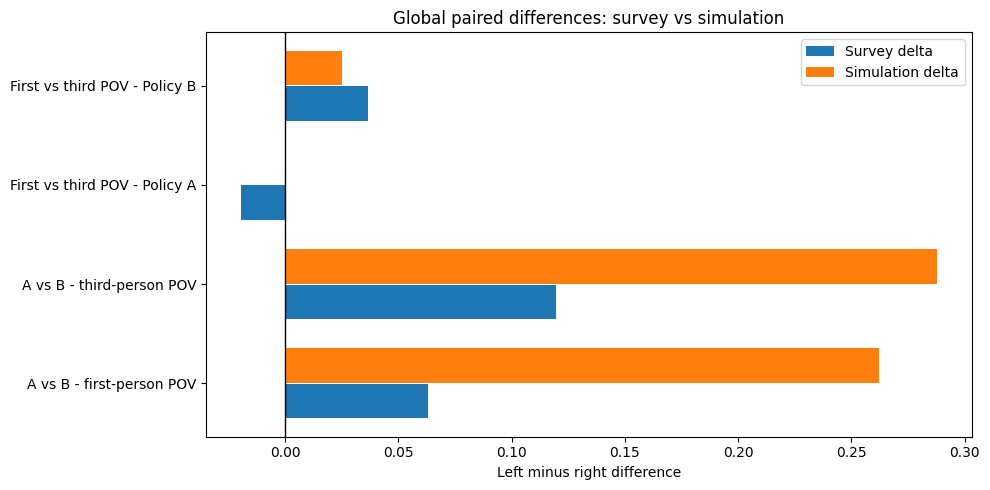

,comparison,survey_mean_delta_norm,survey_mean_delta_ci_low,survey_mean_delta_ci_high,simulation_mean_delta,direction_agreement
0,A vs B - first-person POV,0.063310,0.018747,0.107639,0.262282,agree
5,A vs B - third-person POV,0.119444,0.080208,0.161111,0.287654,agree
10,First vs third POV - Policy A,-0.019444,-0.054167,0.016319,0.000000,agree
15,First vs third POV - Policy B,0.036690,0.000460,0.074653,0.025372,agree


In [52]:
global_comparisons = comparison_results[comparison_results["axis"] == "global"].copy()
positions = np.arange(len(global_comparisons))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(positions - 0.18, global_comparisons["survey_mean_delta_norm"], height=0.35, label="Survey delta")
ax.barh(positions + 0.18, global_comparisons["simulation_mean_delta"], height=0.35, label="Simulation delta")
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(positions)
ax.set_yticklabels(global_comparisons["comparison"])
ax.set_xlabel("Left minus right difference")
ax.set_title("Global paired differences: survey vs simulation")
ax.legend()
plt.tight_layout()
plt.show()

display(global_comparisons[["comparison", "survey_mean_delta_norm", "survey_mean_delta_ci_low", "survey_mean_delta_ci_high", "simulation_mean_delta", "direction_agreement"]])

## Ranking Alignment

This section checks whether the four conditions are ordered similarly by the survey and the simulation. With only four conditions per axis, the rank correlation is descriptive. It is useful as a compact sanity check, not as a final proof.

In [53]:
def rank_correlation(left_values, right_values):
    data = pd.DataFrame({"left": left_values, "right": right_values}).dropna()
    if len(data) < 2:
        return np.nan
    left_ranks = data["left"].rank()
    right_ranks = data["right"].rank()
    if left_ranks.nunique() < 2 or right_ranks.nunique() < 2:
        return np.nan
    return left_ranks.corr(right_ranks)


rank_rows = []
for axis in AXES_WITH_GLOBAL:
    axis_frame = joint_summary[joint_summary["axis"] == axis].dropna(subset=["survey_mean_0_1", "sim_mean_0_1"]).copy()
    rank_rows.append(
        {
            "axis": axis,
            "n_conditions": len(axis_frame),
            "rank_correlation": rank_correlation(axis_frame["survey_mean_0_1"], axis_frame["sim_mean_0_1"]),
            "survey_order_high_to_low": " > ".join(axis_frame.sort_values("survey_mean_0_1", ascending=False)["condition"].str.upper()),
            "simulation_order_high_to_low": " > ".join(axis_frame.sort_values("sim_mean_0_1", ascending=False)["condition"].str.upper()),
        }
    )

rank_alignment = pd.DataFrame(rank_rows)
overall_rank_correlation = rank_correlation(plot_data["survey_mean_0_1"], plot_data["sim_mean_0_1"])

display(rank_alignment)
print(f"Overall descriptive rank correlation across available condition-axis points: {overall_rank_correlation:.3f}")

,axis,n_conditions,rank_correlation,survey_order_high_to_low,simulation_order_high_to_low
0,global,4,0.948683,Q3 > Q1 > Q2 > Q4,Q1 > Q3 > Q2 > Q4
1,competence_control,4,0.948683,Q3 > Q1 > Q2 > Q4,Q1 > Q3 > Q2 > Q4
2,safety,4,0.948683,Q3 > Q1 > Q2 > Q4,Q1 > Q3 > Q2 > Q4
3,awareness,4,0.316228,Q2 > Q3 > Q1 > Q4,Q1 > Q3 > Q2 > Q4
4,positive_impression,4,0.948683,Q1 > Q3 > Q2 > Q4,Q1 > Q3 > Q2 > Q4


Overall descriptive rank correlation across available condition-axis points: 0.618


## Did We Do It Right Or Wrong?

This should be read as a benchmark validation check, not as a moral yes/no. The benchmark is working for this dataset when it predicts the same relative outcomes as the survey. It is not working, or is incomplete, where the survey and simulation disagree in direction or where the simulation has too little evidence.

In [54]:
agreement_summary = (
    comparison_results.groupby(["axis", "direction_agreement"])
    .size()
    .unstack(fill_value=0)
    .reindex(AXES_WITH_GLOBAL)
)

decisive_results = comparison_results[comparison_results["direction_agreement"] != "missing"].copy()
agreement_rate = (decisive_results["direction_agreement"] == "agree").mean()

mismatches = comparison_results[comparison_results["direction_agreement"].isin(["disagree", "one_tie", "missing"])].copy()

display(agreement_summary)
print(f"Agreement rate across comparison rows: {agreement_rate:.1%}")

display(
    mismatches[
        [
            "comparison",
            "axis",
            "survey_mean_delta_norm",
            "survey_mean_delta_ci_low",
            "survey_mean_delta_ci_high",
            "survey_direction",
            "simulation_mean_delta",
            "simulation_direction",
            "direction_agreement",
        ]
    ].sort_values(["axis", "comparison"])
)

direction_agreement,agree,one_tie
axis,,
global,4,0
competence_control,3,1
safety,1,3
awareness,3,1
positive_impression,3,1


Agreement rate across comparison rows: 70.0%


,comparison,axis,survey_mean_delta_norm,survey_mean_delta_ci_low,survey_mean_delta_ci_high,survey_direction,simulation_mean_delta,simulation_direction,direction_agreement
3,A vs B - first-person POV,awareness,-0.025210,-0.082633,0.033613,tie,0.304864,left_higher,one_tie
11,First vs third POV - Policy A,competence_control,-0.038889,-0.083333,0.005556,right_higher,0.000000,tie,one_tie
19,First vs third POV - Policy B,positive_impression,0.026389,-0.012500,0.068056,tie,0.044382,left_higher,one_tie
2,A vs B - first-person POV,safety,0.005556,-0.050000,0.062500,tie,0.295022,left_higher,one_tie
12,First vs third POV - Policy A,safety,-0.034722,-0.077778,0.009722,right_higher,0.000000,tie,one_tie
17,First vs third POV - Policy B,safety,0.048611,0.002778,0.095833,left_higher,0.000005,tie,one_tie



## Axis-wise calibration: offset + scale

We calibrate the simulation axis scores onto the human survey scale using
only the tuning subset. The calibration is monotonic if beta > 0:

     calibrated_sim = alpha + beta * raw_sim

 This should be interpreted as a temporary scale calibration, not as a
 re-learning of the internal metric structure.


In [56]:
CALIBRATION_TUNING_N = 50
CALIBRATION_RANDOM_SEED = RANDOM_SEED

# Calibrate only the four real axes, not "global".
CALIBRATION_AXES = AXES.copy()

rng = np.random.default_rng(CALIBRATION_RANDOM_SEED)

participant_ids = np.array(sorted(survey_analysis_long["participant_id"].dropna().unique()))
rng.shuffle(participant_ids)

tuning_participants = set(participant_ids[:CALIBRATION_TUNING_N])
validation_participants = set(participant_ids[CALIBRATION_TUNING_N:])

print(f"Tuning participants: {len(tuning_participants)}")
print(f"Validation participants: {len(validation_participants)}")

survey_tuning_long = survey_analysis_long[
    survey_analysis_long["participant_id"].isin(tuning_participants)
].copy()

survey_validation_long = survey_analysis_long[
    survey_analysis_long["participant_id"].isin(validation_participants)
].copy()

# %%
def summarize_survey_subset(survey_subset_long, value_column="score_norm"):
    """Mean human score per condition x axis for one participant subset."""
    return (
        survey_subset_long[survey_subset_long["axis"].isin(CALIBRATION_AXES)]
        .groupby(["condition", "condition_label", "policy", "pov", "axis"], dropna=False)
        .agg(
            survey_mean_0_1=(value_column, "mean"),
            survey_std_0_1=(value_column, "std"),
            survey_n=(value_column, "count"),
        )
        .reset_index()
    )


def summarize_simulation_for_calibration(simulation_long, value_column="sim_score"):
    """Mean simulation score per condition x axis."""
    return (
        simulation_long[simulation_long["axis"].isin(CALIBRATION_AXES)]
        .groupby(["condition", "condition_label", "policy", "pov", "axis"], dropna=False)
        .agg(
            sim_mean_0_1=(value_column, "mean"),
            sim_std_0_1=(value_column, "std"),
            sim_n=(value_column, "count"),
        )
        .reset_index()
    )


survey_tuning_summary = summarize_survey_subset(survey_tuning_long)
survey_validation_summary = summarize_survey_subset(survey_validation_long)
simulation_calibration_summary = summarize_simulation_for_calibration(simulation_analysis_long)

calibration_tuning_table = survey_tuning_summary.merge(
    simulation_calibration_summary,
    on=["condition", "condition_label", "policy", "pov", "axis"],
    how="inner",
)

calibration_validation_table = survey_validation_summary.merge(
    simulation_calibration_summary,
    on=["condition", "condition_label", "policy", "pov", "axis"],
    how="inner",
)

display(calibration_tuning_table.sort_values(["axis", "condition"]))

Tuning participants: 50
Validation participants: 70


,condition,condition_label,policy,pov,axis,survey_mean_0_1,survey_std_0_1,survey_n,sim_mean_0_1,sim_std_0_1,sim_n
0,q1,Policy A - first person,A,first_person,awareness,0.376667,0.310091,50,0.835777,0.274348,3
4,q2,Policy B - first person,B,first_person,awareness,0.313333,0.268615,50,0.530912,0.049427,3
8,q3,Policy A - third person,A,third_person,awareness,0.393333,0.264618,50,0.835777,0.274348,3
12,q4,Policy B - third person,B,third_person,awareness,0.313333,0.278968,50,0.474299,0.146776,3
1,q1,Policy A - first person,A,first_person,competence_control,0.540000,0.304092,50,0.842581,0.138905,3
5,q2,Policy B - first person,B,first_person,competence_control,0.350000,0.292092,50,0.631117,0.255745,3
9,q3,Policy A - third person,A,third_person,competence_control,0.583333,0.267791,50,0.842581,0.138905,3
13,q4,Policy B - third person,B,third_person,competence_control,0.330000,0.255306,50,0.630628,0.255564,3
2,q1,Policy A - first person,A,first_person,positive_impression,0.536667,0.297933,50,0.719329,0.180480,3
6,q2,Policy B - first person,B,first_person,positive_impression,0.370000,0.257077,50,0.481553,0.099182,3


In [57]:
# %%
def fit_affine_calibration(x, y, beta_bounds=(0.0, 3.0)):
    """
    Fit y ~= alpha + beta * x.

    x: raw simulation score, expected in 0..1
    y: human survey mean, expected in 0..1

    beta is clipped to beta_bounds to avoid non-monotonic or absurd calibration.
    """
    data = pd.DataFrame({"x": x, "y": y}).dropna()

    if len(data) < 2 or data["x"].nunique() < 2:
        # Fallback: offset-only calibration.
        beta = 1.0
        alpha = float(data["y"].mean() - data["x"].mean()) if len(data) else 0.0
        fit_mode = "offset_only_fallback"
    else:
        beta, alpha = np.polyfit(data["x"], data["y"], deg=1)
        beta = float(np.clip(beta, beta_bounds[0], beta_bounds[1]))

        # Recompute alpha after beta clipping.
        alpha = float(data["y"].mean() - beta * data["x"].mean())
        fit_mode = "affine"

    return alpha, beta, fit_mode


def apply_affine_calibration(x, alpha, beta, clip=True):
    calibrated = alpha + beta * x
    if clip:
        calibrated = np.clip(calibrated, 0.0, 1.0)
    return calibrated


calibration_param_rows = []

for axis in CALIBRATION_AXES:
    axis_train = calibration_tuning_table[calibration_tuning_table["axis"] == axis].copy()

    alpha, beta, fit_mode = fit_affine_calibration(
        x=axis_train["sim_mean_0_1"],
        y=axis_train["survey_mean_0_1"],
        beta_bounds=(0.0, 3.0),
    )

    axis_train["sim_calibrated_0_1"] = apply_affine_calibration(
        axis_train["sim_mean_0_1"], alpha, beta
    )

    raw_mae_train = np.mean(np.abs(axis_train["sim_mean_0_1"] - axis_train["survey_mean_0_1"]))
    calibrated_mae_train = np.mean(np.abs(axis_train["sim_calibrated_0_1"] - axis_train["survey_mean_0_1"]))

    calibration_param_rows.append(
        {
            "axis": axis,
            "alpha": alpha,
            "beta": beta,
            "fit_mode": fit_mode,
            "n_conditions_used": len(axis_train),
            "raw_mae_train_0_1": raw_mae_train,
            "calibrated_mae_train_0_1": calibrated_mae_train,
            "raw_mae_train_0_100": raw_mae_train * 100,
            "calibrated_mae_train_0_100": calibrated_mae_train * 100,
        }
    )

calibration_params = pd.DataFrame(calibration_param_rows)

display(calibration_params)

,axis,alpha,beta,fit_mode,n_conditions_used,raw_mae_train_0_1,calibrated_mae_train_0_1,raw_mae_train_0_100,calibrated_mae_train_0_100
0,competence_control,-0.320624,1.047141,affine,4,0.285894,0.015706,28.589369,1.570550
1,safety,0.207434,0.333306,affine,4,0.139406,0.014166,13.940569,1.416626
2,awareness,0.207269,0.212043,affine,4,0.320025,0.007168,32.002460,0.716779
3,positive_impression,0.063634,0.649929,affine,4,0.142679,0.005545,14.267862,0.554469


In [58]:
# %%
simulation_analysis_long_calibrated = simulation_analysis_long.copy()

simulation_analysis_long_calibrated["sim_score_calibrated"] = simulation_analysis_long_calibrated["sim_score"]

for _, row in calibration_params.iterrows():
    axis = row["axis"]
    alpha = row["alpha"]
    beta = row["beta"]

    mask = simulation_analysis_long_calibrated["axis"] == axis
    simulation_analysis_long_calibrated.loc[mask, "sim_score_calibrated"] = apply_affine_calibration(
        simulation_analysis_long_calibrated.loc[mask, "sim_score"],
        alpha,
        beta,
    )

# Optional: recompute calibrated global as the mean of calibrated axes.
# This is only useful if you still keep the global rows around for plots.
calibrated_axis_rows = simulation_analysis_long_calibrated[
    simulation_analysis_long_calibrated["axis"].isin(CALIBRATION_AXES)
].copy()

calibrated_global = (
    calibrated_axis_rows
    .groupby(["condition", "condition_label", "policy", "pov", "episode_slot", "episode_type"], dropna=False)
    .agg(
        sim_score=("sim_score", "mean"),
        sim_score_calibrated=("sim_score_calibrated", "mean"),
    )
    .reset_index()
)
calibrated_global["axis"] = "global"

simulation_analysis_long_calibrated = pd.concat(
    [
        simulation_analysis_long_calibrated[
            simulation_analysis_long_calibrated["axis"] != "global"
        ],
        calibrated_global,
    ],
    ignore_index=True,
    sort=False,
)

display(simulation_analysis_long_calibrated.head())

,condition,condition_label,policy,pov,episode_slot,episode_type,axis,sim_score,sim_score_calibrated
0,q1,Policy A - first person,A,first_person,ep1,no_obstacles,competence_control,0.928571,0.651722
1,q1,Policy A - first person,A,first_person,ep2,fixed_obstacles,competence_control,0.916843,0.639440
2,q1,Policy A - first person,A,first_person,ep3,moving_people,competence_control,0.682330,0.393872
3,q2,Policy B - first person,B,first_person,ep1,no_obstacles,competence_control,0.850004,0.569451
4,q2,Policy B - first person,B,first_person,ep2,fixed_obstacles,competence_control,0.693346,0.405407


In [59]:
# %%
simulation_summary_calibrated = (
    simulation_analysis_long_calibrated
    .groupby(["condition", "condition_label", "policy", "pov", "axis"], dropna=False)
    .agg(
        sim_mean_0_1=("sim_score", "mean"),
        sim_calibrated_mean_0_1=("sim_score_calibrated", "mean"),
        sim_median_0_1=("sim_score", "median"),
        sim_calibrated_median_0_1=("sim_score_calibrated", "median"),
        sim_std_0_1=("sim_score", "std"),
        sim_calibrated_std_0_1=("sim_score_calibrated", "std"),
        n_episode_values=("sim_score", "count"),
        n_episode_slots=("episode_slot", "nunique"),
    )
    .reset_index()
)

joint_tuning_calibrated = survey_tuning_summary.merge(
    simulation_summary_calibrated,
    on=["condition", "condition_label", "policy", "pov", "axis"],
    how="inner",
)

joint_validation_calibrated = survey_validation_summary.merge(
    simulation_summary_calibrated,
    on=["condition", "condition_label", "policy", "pov", "axis"],
    how="inner",
)

for df in [joint_tuning_calibrated, joint_validation_calibrated]:
    df["raw_gap_sim_minus_survey"] = df["sim_mean_0_1"] - df["survey_mean_0_1"]
    df["calibrated_gap_sim_minus_survey"] = df["sim_calibrated_mean_0_1"] - df["survey_mean_0_1"]
    df["raw_abs_error"] = df["raw_gap_sim_minus_survey"].abs()
    df["calibrated_abs_error"] = df["calibrated_gap_sim_minus_survey"].abs()

display(joint_validation_calibrated.sort_values(["axis", "condition"]))

,condition,condition_label,policy,pov,axis,survey_mean_0_1,survey_std_0_1,survey_n,sim_mean_0_1,sim_calibrated_mean_0_1,sim_median_0_1,sim_calibrated_median_0_1,sim_std_0_1,sim_calibrated_std_0_1,n_episode_values,n_episode_slots,raw_gap_sim_minus_survey,calibrated_gap_sim_minus_survey,raw_abs_error,calibrated_abs_error
0,q1,Policy A - first person,A,first_person,awareness,0.335714,0.263894,70,0.835777,0.384490,0.988271,0.416825,0.274348,0.058174,3,3,0.500062,0.048776,0.500062,0.048776
4,q2,Policy B - first person,B,first_person,awareness,0.427536,0.290759,69,0.530912,0.319846,0.554317,0.324808,0.049427,0.010481,3,3,0.103376,-0.107691,0.103376,0.107691
8,q3,Policy A - third person,A,third_person,awareness,0.354762,0.243963,70,0.835777,0.384490,0.988271,0.416825,0.274348,0.058174,3,3,0.481015,0.029728,0.481015,0.029728
12,q4,Policy B - third person,B,third_person,awareness,0.342857,0.274941,70,0.474299,0.307841,0.553692,0.324676,0.146776,0.031123,3,3,0.131442,-0.035016,0.131442,0.035016
1,q1,Policy A - first person,A,first_person,competence_control,0.523810,0.257396,70,0.842581,0.561678,0.916843,0.639440,0.138905,0.145454,3,3,0.318772,0.037868,0.318772,0.037868
5,q2,Policy B - first person,B,first_person,competence_control,0.376190,0.262660,70,0.631117,0.340244,0.693346,0.405407,0.255745,0.267801,3,3,0.254926,-0.035946,0.254926,0.035946
9,q3,Policy A - third person,A,third_person,competence_control,0.559524,0.257004,70,0.842581,0.561678,0.916843,0.639440,0.138905,0.145454,3,3,0.283058,0.002154,0.283058,0.002154
13,q4,Policy B - third person,B,third_person,competence_control,0.352381,0.231467,70,0.630628,0.339733,0.691893,0.403885,0.255564,0.267612,3,3,0.278247,-0.012648,0.278247,0.012648
2,q1,Policy A - first person,A,first_person,positive_impression,0.490476,0.237210,70,0.719329,0.531147,0.823529,0.598870,0.180480,0.117299,3,3,0.228853,0.040671,0.228853,0.040671
6,q2,Policy B - first person,B,first_person,positive_impression,0.421429,0.246916,70,0.481553,0.376609,0.464283,0.365385,0.099182,0.064461,3,3,0.060124,-0.044819,0.060124,0.044819


In [60]:
# %%
def rank_correlation(left_values, right_values):
    data = pd.DataFrame({"left": left_values, "right": right_values}).dropna()
    if len(data) < 2:
        return np.nan

    left_ranks = data["left"].rank()
    right_ranks = data["right"].rank()

    if left_ranks.nunique() < 2 or right_ranks.nunique() < 2:
        return np.nan

    return left_ranks.corr(right_ranks)


def calibration_evaluation_table(joint_table, split_name):
    rows = []

    for axis in CALIBRATION_AXES:
        axis_df = joint_table[joint_table["axis"] == axis].copy()

        rows.append(
            {
                "split": split_name,
                "axis": axis,
                "n_condition_points": len(axis_df),
                "raw_mae_0_1": axis_df["raw_abs_error"].mean(),
                "calibrated_mae_0_1": axis_df["calibrated_abs_error"].mean(),
                "raw_mae_0_100": axis_df["raw_abs_error"].mean() * 100,
                "calibrated_mae_0_100": axis_df["calibrated_abs_error"].mean() * 100,
                "raw_bias_0_100": axis_df["raw_gap_sim_minus_survey"].mean() * 100,
                "calibrated_bias_0_100": axis_df["calibrated_gap_sim_minus_survey"].mean() * 100,
                "raw_rank_corr": rank_correlation(axis_df["survey_mean_0_1"], axis_df["sim_mean_0_1"]),
                "calibrated_rank_corr": rank_correlation(axis_df["survey_mean_0_1"], axis_df["sim_calibrated_mean_0_1"]),
            }
        )

    return pd.DataFrame(rows)


calibration_evaluation = pd.concat(
    [
        calibration_evaluation_table(joint_tuning_calibrated, "tuning"),
        calibration_evaluation_table(joint_validation_calibrated, "validation"),
    ],
    ignore_index=True,
)

display(calibration_evaluation)

,split,axis,n_condition_points,raw_mae_0_1,calibrated_mae_0_1,raw_mae_0_100,calibrated_mae_0_100,raw_bias_0_100,calibrated_bias_0_100,raw_rank_corr,calibrated_rank_corr
0,tuning,competence_control,4,0.285894,0.015706,28.589369,1.570550,28.589369,-2.775558e-15,0.948683,0.948683
1,tuning,safety,4,0.139406,0.014166,13.940569,1.416626,13.940569,-6.938894e-15,0.948683,0.948683
2,tuning,awareness,4,0.320025,0.007168,32.002460,0.716779,32.002460,-1.387779e-15,0.888889,0.888889
3,tuning,positive_impression,4,0.142679,0.005545,14.267862,0.554469,14.267862,1.387779e-15,0.948683,0.948683
4,validation,competence_control,4,0.283751,0.022154,28.375084,2.215409,28.375084,-2.142857e-01,0.948683,0.948683
5,validation,safety,4,0.159470,0.043810,15.946972,4.380965,14.583427,6.428571e-01,0.500000,0.500000
6,validation,awareness,4,0.303974,0.055303,30.397387,5.530267,30.397387,-1.605072e+00,-0.210819,-0.210819
7,validation,positive_impression,4,0.145893,0.045790,14.589291,4.578973,14.589291,3.214286e-01,0.948683,0.948683


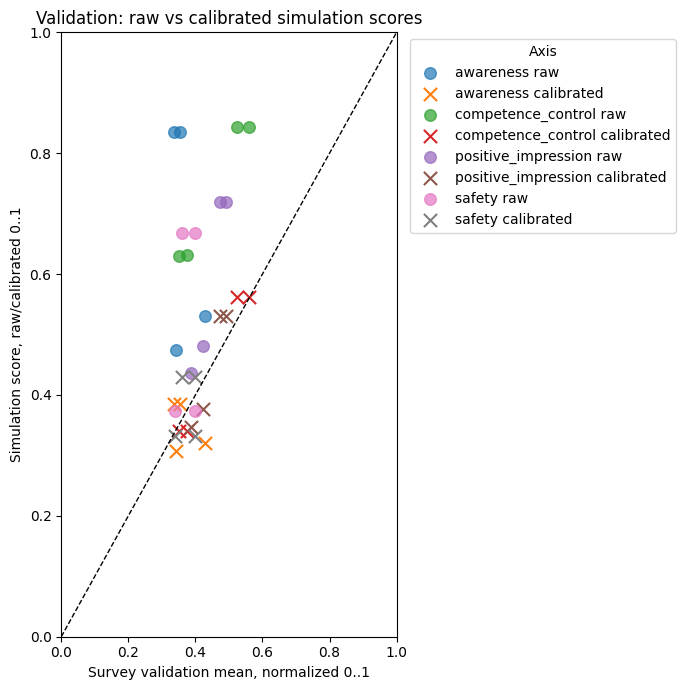

In [61]:
# %%
plot_cal = joint_validation_calibrated.copy()

fig, ax = plt.subplots(figsize=(7, 7))

for axis_name, axis_frame in plot_cal.groupby("axis"):
    ax.scatter(
        axis_frame["survey_mean_0_1"],
        axis_frame["sim_mean_0_1"],
        label=f"{axis_name} raw",
        marker="o",
        s=70,
        alpha=0.7,
    )
    ax.scatter(
        axis_frame["survey_mean_0_1"],
        axis_frame["sim_calibrated_mean_0_1"],
        label=f"{axis_name} calibrated",
        marker="x",
        s=90,
    )

ax.axline((0, 0), slope=1, color="black", linewidth=1, linestyle="--")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Survey validation mean, normalized 0..1")
ax.set_ylabel("Simulation score, raw/calibrated 0..1")
ax.set_title("Validation: raw vs calibrated simulation scores")
ax.legend(title="Axis", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [62]:
# %%
CALIBRATED_SIMULATION_DELTA_THRESHOLD = SIMULATION_DELTA_THRESHOLD

calibrated_comparison_rows = []

for left_condition, right_condition, comparison_name, meaning in COMPARISONS:
    for axis in CALIBRATION_AXES:
        left_survey = (
            survey_validation_long[
                (survey_validation_long["condition"] == left_condition)
                & (survey_validation_long["axis"] == axis)
            ]
            .set_index("participant_id")["score_norm"]
            .rename("left")
        )

        right_survey = (
            survey_validation_long[
                (survey_validation_long["condition"] == right_condition)
                & (survey_validation_long["axis"] == axis)
            ]
            .set_index("participant_id")["score_norm"]
            .rename("right")
        )

        survey_pair = pd.concat([left_survey, right_survey], axis=1, join="inner").dropna()
        survey_deltas = survey_pair["left"] - survey_pair["right"]

        left_sim = (
            simulation_analysis_long_calibrated[
                (simulation_analysis_long_calibrated["condition"] == left_condition)
                & (simulation_analysis_long_calibrated["axis"] == axis)
            ]
            .set_index("episode_slot")["sim_score_calibrated"]
            .rename("left")
        )

        right_sim = (
            simulation_analysis_long_calibrated[
                (simulation_analysis_long_calibrated["condition"] == right_condition)
                & (simulation_analysis_long_calibrated["axis"] == axis)
            ]
            .set_index("episode_slot")["sim_score_calibrated"]
            .rename("right")
        )

        simulation_pair = pd.concat([left_sim, right_sim], axis=1, join="inner").dropna()
        simulation_deltas = simulation_pair["left"] - simulation_pair["right"]

        survey_mean_delta = survey_deltas.mean()
        simulation_mean_delta = simulation_deltas.mean()

        survey_direction = classify_direction(survey_mean_delta, SURVEY_DELTA_THRESHOLD)
        simulation_direction = classify_direction(simulation_mean_delta, CALIBRATED_SIMULATION_DELTA_THRESHOLD)

        calibrated_comparison_rows.append(
            {
                "comparison": comparison_name,
                "axis": axis,
                "left": left_condition,
                "right": right_condition,
                "survey_validation_n": len(survey_deltas),
                "survey_validation_mean_delta": survey_mean_delta,
                "simulation_calibrated_mean_delta": simulation_mean_delta,
                "survey_direction": survey_direction,
                "simulation_calibrated_direction": simulation_direction,
                "direction_agreement": compare_directions(survey_direction, simulation_direction),
            }
        )

calibrated_comparison_results = pd.DataFrame(calibrated_comparison_rows)

display(
    calibrated_comparison_results.sort_values(["axis", "comparison"])
)

,comparison,axis,left,right,survey_validation_n,survey_validation_mean_delta,simulation_calibrated_mean_delta,survey_direction,simulation_calibrated_direction,direction_agreement
2,A vs B - first-person POV,awareness,q1,q2,69,-0.089372,0.064644,right_higher,left_higher,disagree
6,A vs B - third-person POV,awareness,q3,q4,70,0.011905,0.076649,tie,left_higher,one_tie
10,First vs third POV - Policy A,awareness,q1,q3,70,-0.019048,0.000000,tie,tie,agree
14,First vs third POV - Policy B,awareness,q2,q4,69,0.091787,0.012004,left_higher,tie,one_tie
0,A vs B - first-person POV,competence_control,q1,q2,70,0.147619,0.221433,left_higher,left_higher,agree
4,A vs B - third-person POV,competence_control,q3,q4,70,0.207143,0.221945,left_higher,left_higher,agree
8,First vs third POV - Policy A,competence_control,q1,q3,70,-0.035714,0.000000,right_higher,tie,one_tie
12,First vs third POV - Policy B,competence_control,q2,q4,70,0.023810,0.000511,tie,tie,agree
3,A vs B - first-person POV,positive_impression,q1,q2,70,0.069048,0.154538,left_higher,left_higher,agree
7,A vs B - third-person POV,positive_impression,q3,q4,70,0.085714,0.183383,left_higher,left_higher,agree


### How To Interpret The Output

A useful benchmark should usually satisfy these checks:

- The survey paired differences are stable enough to interpret, ideally with bootstrap intervals that do not cross zero for the main comparisons.
- The simulation deltas have the same direction as the survey deltas for the same policy/POV comparison.
- The rank order of Q1, Q2, Q3, and Q4 is similar between survey and simulation.
- The simulation has valid runs for every condition and episode slot.

Important limits:

- The current survey order was fixed, so order effects are possible.
- The simulation side has episode/run variability, not participant variability.
- If the simulation scores are saturated near `1.0`, the benchmark may not be calibrated even when it ranks correctly.
- With only three episode slots, simulation-side statistical claims should stay descriptive.

So the practical conclusion is: if the direction agreement and rank alignment are high, the benchmark is directionally useful. If they are low, the metric model or weighting is probably not matching human perception yet.

In [72]:
# %% [markdown]
# ## Human A/B preference test on validation set
#
# Tests whether the human survey ratings prefer Policy A over Policy B
# on each subjective axis, using:
# - mean difference A - B
# - bootstrap confidence interval
# - independent permutation test

# %%
import numpy as np
import pandas as pd
from scipy import stats

print("Available policy labels:")
print(sorted(survey_validation_long["policy"].dropna().unique()))

# Change these if your actual labels are different.
POLICY_A_LABEL = "A"
POLICY_B_LABEL = "B"

# Use only the four survey axes, not global/diagnostics.
# This assumes CALIBRATION_AXES already exists.
# Otherwise uncomment and edit:
# CALIBRATION_AXES = ["competence_control", "safety", "awareness", "positive_impression"]


def clean_numeric(values):
    """Convert to float array and remove NaNs."""
    values = np.asarray(values, dtype=float)
    return values[~np.isnan(values)]


def independent_permutation_test_mean_difference(
    left_values,
    right_values,
    n_perm=20_000,
    seed=RANDOM_SEED,
):
    """
    Two-sided permutation test for mean(left) - mean(right).

    H0: both groups come from the same distribution.
    """
    left_values = clean_numeric(left_values)
    right_values = clean_numeric(right_values)

    if len(left_values) == 0 or len(right_values) == 0:
        return np.nan, np.nan

    observed = np.mean(left_values) - np.mean(right_values)

    pooled = np.concatenate([left_values, right_values])
    n_left = len(left_values)

    rng = np.random.default_rng(seed)
    permuted = np.empty(n_perm)

    for i in range(n_perm):
        shuffled = rng.permutation(pooled)
        perm_left = shuffled[:n_left]
        perm_right = shuffled[n_left:]
        permuted[i] = np.mean(perm_left) - np.mean(perm_right)

    p_value = (np.sum(np.abs(permuted) >= abs(observed)) + 1) / (n_perm + 1)

    return observed, p_value


def bootstrap_independent_mean_diff_ci(
    left_values,
    right_values,
    n_boot=10_000,
    ci=0.95,
    seed=RANDOM_SEED,
):
    """
    Bootstrap CI for mean(left) - mean(right).
    Returned values are in the same scale as the inputs.
    """
    left_values = clean_numeric(left_values)
    right_values = clean_numeric(right_values)

    if len(left_values) == 0 or len(right_values) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    boot_deltas = np.empty(n_boot)

    for i in range(n_boot):
        boot_left = rng.choice(left_values, size=len(left_values), replace=True)
        boot_right = rng.choice(right_values, size=len(right_values), replace=True)
        boot_deltas[i] = np.mean(boot_left) - np.mean(boot_right)

    alpha = 1 - ci
    observed = np.mean(left_values) - np.mean(right_values)
    ci_low = np.quantile(boot_deltas, alpha / 2)
    ci_high = np.quantile(boot_deltas, 1 - alpha / 2)

    return observed, ci_low, ci_high


human_policy_test_rows = []

for axis in CALIBRATION_AXES:
    df_axis = survey_validation_long[
        survey_validation_long["axis"] == axis
    ].copy()

    a_values_raw = df_axis[df_axis["policy"] == POLICY_A_LABEL]["score_norm"].to_numpy()
    b_values_raw = df_axis[df_axis["policy"] == POLICY_B_LABEL]["score_norm"].to_numpy()

    a_values = clean_numeric(a_values_raw)
    b_values = clean_numeric(b_values_raw)

    delta_0_1, p_perm = independent_permutation_test_mean_difference(
        a_values,
        b_values,
    )

    delta_boot_0_1, ci_low_0_1, ci_high_0_1 = bootstrap_independent_mean_diff_ci(
        a_values,
        b_values,
    )

    if np.isnan(delta_0_1):
        human_prefers = "undefined"
    elif delta_0_1 > 0:
        human_prefers = "A"
    elif delta_0_1 < 0:
        human_prefers = "B"
    else:
        human_prefers = "tie"

    preference_is_stable_95ci = (
        (ci_low_0_1 > 0 and ci_high_0_1 > 0)
        or (ci_low_0_1 < 0 and ci_high_0_1 < 0)
    )

    human_policy_test_rows.append(
        {
            "axis": axis,
            "n_policy_A": len(a_values),
            "n_policy_B": len(b_values),
            "human_A_mean_0_100": np.mean(a_values) * 100 if len(a_values) else np.nan,
            "human_B_mean_0_100": np.mean(b_values) * 100 if len(b_values) else np.nan,
            "human_delta_A_minus_B_0_100": delta_0_1 * 100 if not np.isnan(delta_0_1) else np.nan,
            "bootstrap_ci_low_0_100": ci_low_0_1 * 100 if not np.isnan(ci_low_0_1) else np.nan,
            "bootstrap_ci_high_0_100": ci_high_0_1 * 100 if not np.isnan(ci_high_0_1) else np.nan,
            "permutation_p_two_sided": p_perm,
            "human_prefers": human_prefers,
            "preference_is_stable_95ci": preference_is_stable_95ci,
        }
    )

human_policy_test_results = pd.DataFrame(human_policy_test_rows)

display(human_policy_test_results)

Available policy labels:
['A', 'B']


,axis,n_policy_A,n_policy_B,human_A_mean_0_100,human_B_mean_0_100,human_delta_A_minus_B_0_100,bootstrap_ci_low_0_100,bootstrap_ci_high_0_100,permutation_p_two_sided,human_prefers,preference_is_stable_95ci
0,competence_control,140,140,54.166667,36.428571,17.738095,11.904762,23.571429,0.000050,A,True
1,safety,140,140,37.976190,36.904762,1.071429,-5.119048,7.261905,0.748313,A,False
2,awareness,140,139,34.523810,38.489209,-3.965399,-10.066804,2.480366,0.217189,B,False
3,positive_impression,140,140,48.214286,40.476190,7.738095,2.261905,13.214286,0.006800,A,True


In [73]:
# %% [markdown]
# ## Backend A/B agreement with human validation preference

# %%
backend_policy_summary = (
    simulation_analysis_long_calibrated[
        simulation_analysis_long_calibrated["axis"].isin(CALIBRATION_AXES)
    ]
    .groupby(["policy", "axis"], dropna=False)
    .agg(
        backend_raw_mean_0_100=("sim_score", lambda x: np.mean(x) * 100),
        backend_calibrated_mean_0_100=("sim_score_calibrated", lambda x: np.mean(x) * 100),
    )
    .reset_index()
)

backend_policy_test_rows = []

for axis in CALIBRATION_AXES:
    axis_backend = backend_policy_summary[
        backend_policy_summary["axis"] == axis
    ]

    human_match = human_policy_test_results[
        human_policy_test_results["axis"] == axis
    ]

    if human_match.empty:
        continue

    human_row = human_match.iloc[0]

    try:
        a_backend_raw = axis_backend[
            axis_backend["policy"] == POLICY_A_LABEL
        ]["backend_raw_mean_0_100"].iloc[0]

        b_backend_raw = axis_backend[
            axis_backend["policy"] == POLICY_B_LABEL
        ]["backend_raw_mean_0_100"].iloc[0]

        a_backend_cal = axis_backend[
            axis_backend["policy"] == POLICY_A_LABEL
        ]["backend_calibrated_mean_0_100"].iloc[0]

        b_backend_cal = axis_backend[
            axis_backend["policy"] == POLICY_B_LABEL
        ]["backend_calibrated_mean_0_100"].iloc[0]

    except IndexError:
        print(f"Skipping axis {axis}: missing backend values for A or B.")
        continue

    human_delta = human_row["human_delta_A_minus_B_0_100"]
    backend_raw_delta = a_backend_raw - b_backend_raw
    backend_cal_delta = a_backend_cal - b_backend_cal

    human_direction = np.sign(human_delta)
    backend_raw_direction = np.sign(backend_raw_delta)
    backend_cal_direction = np.sign(backend_cal_delta)

    human_stable = bool(human_row["preference_is_stable_95ci"])

    backend_policy_test_rows.append(
        {
            "axis": axis,
            "human_delta_A_minus_B_0_100": human_delta,
            "human_ci_low_0_100": human_row["bootstrap_ci_low_0_100"],
            "human_ci_high_0_100": human_row["bootstrap_ci_high_0_100"],
            "human_p_two_sided": human_row["permutation_p_two_sided"],
            "human_prefers": human_row["human_prefers"],
            "human_preference_stable_95ci": human_stable,

            "backend_raw_A_mean_0_100": a_backend_raw,
            "backend_raw_B_mean_0_100": b_backend_raw,
            "backend_raw_delta_A_minus_B_0_100": backend_raw_delta,

            "backend_calibrated_A_mean_0_100": a_backend_cal,
            "backend_calibrated_B_mean_0_100": b_backend_cal,
            "backend_calibrated_delta_A_minus_B_0_100": backend_cal_delta,

            "raw_direction_agrees": human_direction == backend_raw_direction,
            "calibrated_direction_agrees": human_direction == backend_cal_direction,

            # More useful interpretation:
            # If humans are not stable, we should not treat disagreement as a hard failure.
            "raw_result_interpretation": (
                "agreement_on_stable_human_preference"
                if human_stable and human_direction == backend_raw_direction
                else "disagreement_on_stable_human_preference"
                if human_stable and human_direction != backend_raw_direction
                else "human_preference_inconclusive"
            ),
            "calibrated_result_interpretation": (
                "agreement_on_stable_human_preference"
                if human_stable and human_direction == backend_cal_direction
                else "disagreement_on_stable_human_preference"
                if human_stable and human_direction != backend_cal_direction
                else "human_preference_inconclusive"
            ),
        }
    )

backend_policy_test_results = pd.DataFrame(backend_policy_test_rows)

display(backend_policy_test_results)

,axis,human_delta_A_minus_B_0_100,human_ci_low_0_100,human_ci_high_0_100,human_p_two_sided,human_prefers,human_preference_stable_95ci,backend_raw_A_mean_0_100,backend_raw_B_mean_0_100,backend_raw_delta_A_minus_B_0_100,backend_calibrated_A_mean_0_100,backend_calibrated_B_mean_0_100,backend_calibrated_delta_A_minus_B_0_100,raw_direction_agrees,calibrated_direction_agrees,raw_result_interpretation,calibrated_result_interpretation
0,competence_control,17.738095,11.904762,23.571429,0.000050,A,True,84.258149,63.087256,21.170893,56.167790,33.998876,22.168914,True,True,agreement_on_stable_human_preference,agreement_on_stable_human_preference
1,safety,1.071429,-5.119048,7.261905,0.748313,A,False,66.775143,37.272663,29.502480,43.000013,33.166654,9.833358,True,True,human_preference_inconclusive,human_preference_inconclusive
2,awareness,-3.965399,-10.066804,2.480366,0.217189,B,False,83.577678,50.260575,33.317104,38.449004,31.384329,7.064675,False,False,human_preference_inconclusive,human_preference_inconclusive
3,positive_impression,7.738095,2.261905,13.214286,0.006800,A,True,71.932912,45.936146,25.996766,53.114687,36.218646,16.896040,True,True,agreement_on_stable_human_preference,agreement_on_stable_human_preference


## Result summary
The survey shows a stable human preference for Policy A over Policy B
on competence/control and positive impression.

The calibrated testbench reproduces the same A > B direction
on both stable axes.

For safety and awareness, the survey itself is inconclusive,
so disagreement or agreement there should not be treated as a strong success/failure.